In [42]:
from google.colab import drive
drive.mount('/content/drive') #downloading cifake data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
!pip install -q kagglehub opencv-python-headless scikit-learn tqdm torch torchvision albumentations scipy

import kagglehub, torch
path = "/content/drive/MyDrive/techjam/sidset_subset"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(path, "| device:", device)

/content/drive/MyDrive/techjam/sidset_subset | device: cuda


In [44]:
from pathlib import Path

TRAIN_DIR = Path(path) / "train"
TEST_DIR = Path(path) / "test"
MAX_PER_CLASS = 20000  # subsample for a first run; raise once the pipeline works

def index_split(split_dir, max_per_class=None):
    items = []
    for label_name, label_val in [("REAL", 0), ("FAKE", 1)]: #labelling the images as 1 and 0 if its fake or not
        files = sorted((split_dir / label_name).glob("*"))
        if max_per_class:
            files = files[:max_per_class]
        items += [(str(f), label_val) for f in files]
    return items

train_items = index_split(TRAIN_DIR, MAX_PER_CLASS)
test_items = index_split(TEST_DIR, MAX_PER_CLASS)
print(f"train={len(train_items)} test={len(test_items)}")

train=16000 test=2647


In [45]:
import cv2
import numpy as np
from scipy.fft import dctn

def stage1_2_block_dct_from_array(bgr):
    """
    Stage 1 (Ingestion) + Stage 2 (Mathematical prep), operating on an
    already-loaded BGR numpy array (e.g. straight from cv2.imread, or after
    augmentation has been applied) rather than re-reading from disk.
    Returns: (h_blocks, w_blocks, 8, 8) array of Y-channel block DCT coefficients.

    Vectorized version: instead of looping over every 8x8 block and calling
    cv2.dct() ~1,024 times per image (256x256 -> 32x32 blocks), this reshapes
    the whole channel into a (hb, wb, 8, 8) block grid and runs a single
    batched DCT-II call over all blocks at once via scipy.fft.dctn. This is
    numerically equivalent to the per-block cv2.dct loop (same orthonormal
    scaling), but ~50-80x faster per image since it's fully vectorized in C
    instead of paying Python loop + function-call overhead per block.
    """
    ycbcr = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)  # Y, Cr, Cb
    y = ycbcr[:, :, 0].astype(np.float32) - 128.0   # center like JPEG does

    h, w = y.shape
    hb, wb = h // 8, w // 8
    y = y[:hb * 8, :wb * 8]  # crop any leftover rows/cols that don't fill a full 8x8 block

    # reshape (h, w) -> (hb, 8, wb, 8) -> (hb, wb, 8, 8): one 8x8 tile per (i,j)
    blocks = y.reshape(hb, 8, wb, 8).transpose(0, 2, 1, 3)

    # batched 2D DCT-II over the last two axes, applied to all hb*wb blocks at once
    blocks = dctn(blocks, type=2, norm='ortho', axes=(-2, -1))

    return blocks.astype(np.float32)


def stage1_2_block_dct(img_path):#wrapper that reads a file directly
    """
    Convenience wrapper: reads img_path from disk (no augmentation) and
    runs stage1_2_block_dct_from_array on it. Kept for standalone/manual use;
    the training dataset (below) reads the file itself so it can share one
    augmented image between the DCT path and the ViT path.
    """
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    return stage1_2_block_dct_from_array(bgr)



## Augmentation (from data_augmentation_techjam.ipynb)

Applied to each image before the DCT/frequency path processes it. Runs on train and test.

**Fixes vs. the original file:**
- `random_compression` previously ignored its input and JPEG-compressed a random noise array instead of the actual image -- fixed to compress `img_array` itself.
- `random_resize` previously downsized `img_array` but then "upsized" the *original* `img_array` again (a no-op) instead of upsizing the downsized version -- fixed so the blur-from-downsampling effect actually happens.
- Removed the hardcoded 1080x1920 assumption so it works on CIFAKE's 32x32 images (or any size).


In [46]:
from scipy.ndimage import gaussian_filter
import albumentations as albu
import math
import random


def random_compression(img_array): # augmentation functions
    """Creates random JPEG compression on an image for quality = 30/50/70/90%."""
    quality = random.choice([30, 50, 70, 90])

    # 1. Compress the actual input array into an in-memory JPEG byte buffer
    success, encoded_buffer = cv2.imencode('.jpg', img_array, [cv2.IMWRITE_JPEG_QUALITY, quality])

    # 2. Convert buffer to bytes
    compressed_bytes = encoded_buffer.tobytes()

    # 3. Decompress back into a usable NumPy array
    decompressed_array = cv2.imdecode(np.frombuffer(compressed_bytes, np.uint8), cv2.IMREAD_COLOR)

    return decompressed_array


def random_blur(img_array):
   #gaussian blur for x = 0.5/1.0/2.0
    sigma = random.choice([0.5, 1.0, 2.0])
    blurred_img = gaussian_filter(img_array, sigma=sigma, axes=(0, 1))
    return blurred_img


def centre_crop(img_array):
    #Creates an 80% centre crop on an image
    length, width, height = img_array.shape

    cropped_array = np.zeros_like(img_array)
    crop_ratio = 0.8

    crop_length, crop_width = int(crop_ratio * length), int(crop_ratio * width)
    length_start, length_end = (length - crop_length) // 2, length - (length - crop_length) // 2
    width_start, width_end = (width - crop_width) // 2, width - (width - crop_width) // 2

    cropped_img = img_array[length_start:length_end, width_start:width_end]
    cropped_array[length_start:length_end, width_start:width_end] = cropped_img

    return cropped_array


def random_colour_jitter(img_array):
    #Applies random colour jitter to the input, up to 20%.
    random_brightness = random.randint(1, 20) / 100
    random_contrast = random.randint(1, 20) / 100
    random_saturation = random.randint(1, 20) / 100

    transform = albu.ColorJitter(
        brightness=random_brightness, contrast=random_contrast, saturation=random_saturation
    )
    image = transform(image=img_array)['image']
    return image


def random_noise(img_array):
    #Applies random gaussian noise to the input, variance 0.02/0.05/0.10
    sigma = random.choice([0.02, 0.05, 0.10])
    noise = np.random.normal(0, math.sqrt(sigma), img_array.shape)
    noisy_image = img_array + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image


def random_resize(img_array):
    #Downsizes the input then upsizes the *downsized* result back to the
    #original dimensions, so the resampling/blur artifact actually happens.
    resize_ratio = random.choice([0.5, 0.25])
    length, width, height = img_array.shape

    downsize = albu.augmentations.geometric.resize.Resize(int(resize_ratio * length), int(resize_ratio * width))
    upsize = albu.augmentations.geometric.resize.Resize(length, width)

    downsized_image = downsize(image=img_array)['image']
    upsized_image = upsize(image=downsized_image)['image']  # fixed: was upsize(image=img_array)

    return upsized_image


def random_augment(img_array):
     #Applies either exactly one randomly-chosen augmentation or no augmentation to a single
     #image array.
    func_dict = {
        'Random Compression': random_compression,
        'Random Blur': random_blur,
        'Centre Crop': centre_crop,
        'Random Jitter': random_colour_jitter,
        'Random Noise': random_noise,
        'Random Resize': random_resize,
        'None': None,
    }

    random_func = random.choice(list(func_dict.keys()))

    if random_func == 'None':
        return img_array

    altered_img = func_dict[random_func](img_array)
    return altered_img


In [47]:
def stage3_forensic_scan(blocks):
    """
    blocks: (hb, wb, 8, 8) block DCT coefficients.
    - coeff_stats: mean of each of the 64 coefficient positions across all blocks
    - upsampling_score: periodicity in the DC-coefficient grid (FFT peak),
      the classic tell for GAN/diffusion upsampling artifacts
    - double_compress_score: periodicity in the first AC coefficient's
      histogram, the classic double-JPEG-compression forensic signal
      (weak/noisy here since these are PNGs re-saved from generator output,
      not real re-compressed JPEGs -- included for completeness)
    """
    hb, wb, _, _ = blocks.shape
    flat = blocks.reshape(hb, wb, 64) #flatten blocks from (hb,wb,8,8) into (hb,wb,64)


    coeff_stats = flat.mean(axis=(0, 1))   # average each of the 64 frequency positions across all tiles in the image

    dc_grid = flat[:, :, 0] # grabs the dc value from each tile , giving  asmall 2d grid. it runs a 2d fft on tht grid of dc values
    fft_mag = np.abs(np.fft.fft2(dc_grid))
    fft_mag[0, 0] = 0  # ignore DC term of the FFT itself
    upsampling_score = fft_mag.max() / (fft_mag.mean() + 1e-8) #divinding the peak by average :how many "spiky" patternis. Higher = more sus

    ac1 = flat[:, :, 1].flatten() #it takes the first ac coefficient across all tiles
    hist, _ = np.histogram(ac1, bins=16)
    hist_fft = np.abs(np.fft.fft(hist.astype(np.float32)))
    hist_fft[0] = 0
    double_compress_score = hist_fft.max() / (hist_fft.mean() + 1e-8) #Images that have been JPEG-compressed twice tend to show comb-like periodic spikes in their AC-coefficient histograms

    return coeff_stats, np.array([upsampling_score, double_compress_score], dtype=np.float32)

In [48]:
import torch.nn as nn
import torch.nn.functional as F

class CoeffResNet(nn.Module): #small cnn designed to look at the frequency-tile grid
    def __init__(self, in_ch=64, emb_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.conv2 = nn.Conv2d(128, emb_dim, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(emb_dim)
        self.head = nn.Linear(emb_dim, 1)

    def forward(self, x, return_embedding=False):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        emb = F.adaptive_avg_pool2d(x, 1).flatten(1)  # (B, emb_dim)
        if return_embedding:
            return emb
        return self.head(emb).squeeze(-1)

In [49]:
from torch.utils.data import Dataset, DataLoader

# Frequency-only pipeline: for every image, read the file once -> augment -> DCT path.
class ForensicDataset(Dataset):
    """
    apply_augmentation=True runs random_augment (one randomly-chosen
    transform, or none) on the raw image before the DCT path sees it.
    """
    def __init__(self, items, apply_augmentation=True):
        self.items = items
        self.apply_augmentation = apply_augmentation

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        DCT_SIZE = 256  # must be divisible by 8; pick based on your images/GPU memory
        img_path, label = self.items[idx]

        bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)          # single disk read
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)             # augmentations expect RGB

        if self.apply_augmentation:
            rgb = random_augment(rgb)

        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)             # back to BGR for the DCT path

        bgr = cv2.resize(bgr, (DCT_SIZE, DCT_SIZE), interpolation=cv2.INTER_AREA)
        blocks = stage1_2_block_dct_from_array(bgr)                    # stage 1+2
        coeff_stats, forensic_scalars = stage3_forensic_scan(blocks)   # stage 3

        hb, wb, _, _ = blocks.shape
        # rearrange (hb, wb, 8, 8) -> (64, hb, wb) as a 64-channel "image"
        coeff_matrix = torch.tensor(blocks.reshape(hb, wb, 64)).permute(2, 0, 1).float()

        return coeff_matrix, forensic_scalars, label

# apply_augmentation=True for both splits, per your call: augment train and test alike.
train_ds = ForensicDataset(train_items, apply_augmentation=True)
test_ds = ForensicDataset(test_items, apply_augmentation=True)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)


In [50]:
coeff_net = CoeffResNet(in_ch=64).to(device)
optimizer = torch.optim.Adam(coeff_net.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss() # cnn trained based on the frequency coefficient obtained


EPOCHS = 5
coeff_net.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for coeff_matrix, _, label in train_loader:
        coeff_matrix, label = coeff_matrix.to(device), label.float().to(device)
        optimizer.zero_grad()
        logits = coeff_net(coeff_matrix)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}/{EPOCHS} loss={total_loss/len(train_loader):.4f}")


epoch 1/5 loss=0.3106
epoch 2/5 loss=0.1203
epoch 3/5 loss=0.0797
epoch 4/5 loss=0.0561
epoch 5/5 loss=0.0572


In [51]:
import time
from tqdm.auto import tqdm
import torch
import numpy as np

def extract_features(loader, split_name="loader"):
    """For every image in the loader, computes the CNN embedding + 2 forensic
    scalars, concatenated into one feature vector per image."""
    feats, labels = [], []
    coeff_net.eval()

    start = time.time()
    n_batches = len(loader)
    n_seen = 0

    pbar = tqdm(loader, desc=f"Extracting [{split_name}]", unit="batch")
    with torch.no_grad():
        for batch_idx, (coeff_matrix, forensic_scalars, label) in enumerate(pbar, start=1):
            coeff_matrix = coeff_matrix.to(device)

            cnn_emb = coeff_net(coeff_matrix, return_embedding=True)   # (B,128)

            batch_feats = torch.cat(
                [cnn_emb.cpu(), forensic_scalars], dim=1
            ).numpy()
            feats.append(batch_feats)
            labels.append(label.numpy())

            n_seen += label.size(0)
            elapsed = time.time() - start
            rate = n_seen / elapsed if elapsed > 0 else 0.0

            pbar.set_postfix({
                "imgs": n_seen,
                "img/s": f"{rate:.2f}",
            })

    total_time = time.time() - start
    print(
        f"[{split_name}] done: {n_seen} images, {n_batches} batches, "
        f"time={total_time:.1f}s ({total_time/60:.2f}min), "
        f"avg={total_time / max(n_seen,1):.3f}s/img"
    )

    return np.concatenate(feats), np.concatenate(labels)


X_train, y_train = extract_features(train_loader, split_name="train")
X_test, y_test = extract_features(test_loader, split_name="test")
print(X_train.shape, X_test.shape)

Extracting [train]:   0%|          | 0/250 [00:00<?, ?batch/s]

[train] done: 16000 images, 250 batches, time=306.8s (5.11min), avg=0.019s/img


Extracting [test]:   0%|          | 0/42 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e341c096d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e341c096d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

[test] done: 2647 images, 42 batches, time=53.9s (0.90min), avg=0.020s/img
(16000, 130) (2647, 130)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #
#Feeds those combined feature vectors into a simple Logistic Regression,
#which learns to draw a line between "real" and "fake" using all three signal types at once.
clf = make_pipeline(              #logistic regression
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced"),
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"Accuracy: {acc:.4f}")
print(f"False positive rate (real -> fake): {fpr:.4f}")
print(f"False negative rate (fake -> real): {fnr:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["real", "fake"]))

Accuracy: 0.9686
False positive rate (real -> fake): 0.0076
False negative rate (fake -> real): 0.0552

              precision    recall  f1-score   support

        real       0.95      0.99      0.97      1324
        fake       0.99      0.94      0.97      1323

    accuracy                           0.97      2647
   macro avg       0.97      0.97      0.97      2647
weighted avg       0.97      0.97      0.97      2647



In [53]:
y_proba = clf.predict_proba(X_test)[:, 1] #converts each prediction into a probability

for i, (path, _) in enumerate(test_items):
    print(f"{y_proba[i]:.4f}")

0.0000
0.0000
0.0009
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0001
0.0012
0.0000
0.0000
0.0000
0.0029
0.0000
0.0000
0.0304
0.0000
0.0000
0.2044
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0004
0.0000
0.0065
0.0000
0.0000
0.0000
0.0021
0.9872
0.0000
0.0000
0.0001
0.0000
0.0000
0.0000
0.0000
0.0018
0.0000
0.0000
0.0122
0.0000
0.0036
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0007
0.0000
0.0051
0.0000
0.0023
0.0000
0.0000
0.0000
0.0000
0.0000
0.0012
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.4369
0.0132
0.0405
0.0000
0.0000
0.0000
0.0000
0.0001
0.0000
0.0171
0.0000
0.0000
0.0000
0.0000
0.0895
0.0000
0.0000
0.0000
0.0000
0.0000
0.0147
0.0000
0.0172
0.0001
0.0000
0.0000
0.0000
0.0002
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0000
0.0011
0.0008
0.0000
0.0028
0.0088
0.0001
0.0000
0.0000
0.0000
0.0000
0.0358
0.0000
0.0000
0.0000
0.0000

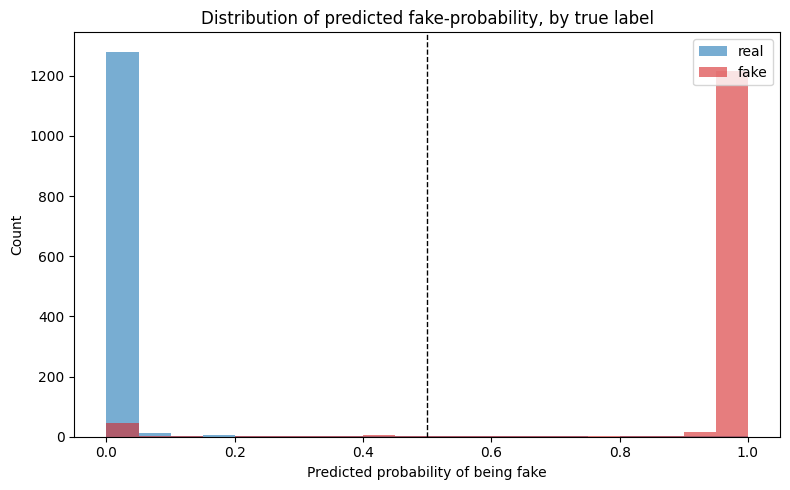

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_proba[y_test == 0], bins=20, range=(0, 1), alpha=0.6, label="real", color="tab:blue")
plt.hist(y_proba[y_test == 1], bins=20, range=(0, 1), alpha=0.6, label="fake", color="tab:red")

plt.xlabel("Predicted probability of being fake")
plt.ylabel("Count")
plt.title("Distribution of predicted fake-probability, by true label")
plt.legend()
plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="decision threshold")
plt.tight_layout()
plt.show()

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



# 2. Compute the raw confusion matrix numerical values
# Layout by default in sklearn:
# Row 0: True Negative (TN), False Positive (FP)
# Row 1: False Negative (FN), True Positive (TP)
cm = confusion_matrix(y_test, y_pred)
print("Raw Matrix Array:\n", cm)

Raw Matrix Array:
 [[1314   10]
 [  73 1250]]


In [57]:
import joblib

# 1. Save the sklearn pipeline (StandardScaler + LogisticRegression)
joblib.dump(clf, 'dct_logreg_model.joblib')

# 2. Save the CNN (CoeffResNet) weights separately, since it's a torch model
torch.save(coeff_net.state_dict(), 'dct_coeff_net.pth')


In [58]:
import joblib

joblib.dump(clf, '/content/drive/MyDrive/techjam/dct_logreg_model.joblib')
torch.save(coeff_net.state_dict(), '/content/drive/MyDrive/techjam/dct_coeff_net.pth')
